# Figure 3: Functional classification of GCL responses

---
## Imports

In [16]:
import os
from all_gcl_manuscript.paths import REPO_DIR
from all_gcl_manuscript import style

FIG_DIR = os.path.join(REPO_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
style.set_rc_params()

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

---
## Load and quality filter dataset

In [3]:
from all_gcl_manuscript.utils import restore_numpy_arrays

dataset_path = "/gpfs01/euler/data/Resources/All-GCL/database/"
all_gcl_df = pd.read_parquet(os.path.join(dataset_path, "all_GCL_table.parquet"))
all_gcl_df = restore_numpy_arrays(all_gcl_df)

Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: srf


In [4]:
from all_gcl_manuscript.dataframe import filter_df

all_gcl_df = filter_df(
    df=all_gcl_df,
    condition_filter=True,
    quality_filter=True,
    location_filter=False,
    genline_filter=True,
    rf_quality_filter=False,
    verbose=True
)

Filtering condition. Removing 19% of the data.
Filtering quality. Removing 30% of the data.
Filtering genline. Removing 0% of the data.


In [5]:
label_encoder = LabelEncoder()
encoded_experimenter = label_encoder.fit_transform(all_gcl_df['experimenter'].values)

label_encoder = LabelEncoder()
encoded_gender = label_encoder.fit_transform(all_gcl_df['animgender'].values)

all_gcl_df['experimenter_id'] = encoded_experimenter + 1
all_gcl_df['age'] = all_gcl_df['age'].astype(int)
all_gcl_df['age_weeks'] = all_gcl_df['age'] / 7

In [6]:
# extract mean traces for plotting
chirp_data = np.stack(all_gcl_df['preproc_chirp'])
bar_data_time = np.stack(all_gcl_df['preproc_bar'])
filtered_trf = all_gcl_df.dropna(subset=['trf']).reset_index(drop=True)
trf_data = np.stack(filtered_trf['trf'])

---
## Plotting: Group distribution and cells per field

In [10]:
from all_gcl_manuscript import labels

colors = ['tab:red'] * 9 + ['gold'] * 5 + ['tab:green'] * 6 + ['tab:blue'] * 8 + ['tab:purple'] * 4 + ['gray'] * 14
group_ticks = np.arange(1, 47, 1)
name_ticklabels = [labels.baden_group_id_to_group_name(i, shorten=True) for i in group_ticks]
group_ticklabels = [rf"G$_{{{i}}}$" for i in group_ticks]
group_and_name_ticklabels = [group + ': ' + name for group, name in zip(group_ticklabels, name_ticklabels)]

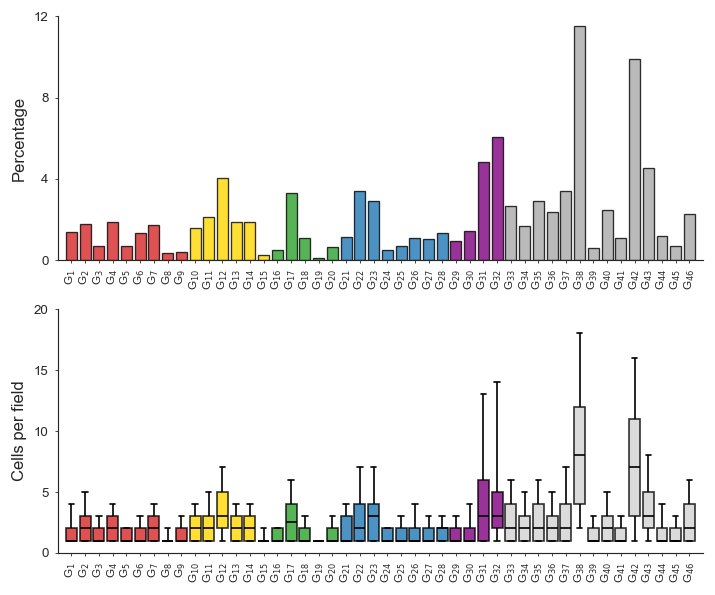

In [11]:
save = 1
fontsize_labels = 10

fig, ax = plt.subplot_mosaic("""
AAAA
BBBB
""", figsize=(6, 5))

###########################################
#####  Group distribution
###########################################
group_order = np.arange(1, len(group_ticks) + 1)
percentages = (all_gcl_df['group_id'].value_counts(normalize=True).reindex(group_order, fill_value=0) * 100)
percent_data = pd.DataFrame({'group_id': group_order, 'percentage': percentages.values})
bars = sns.barplot(data=percent_data, x='group_id', y='percentage', order=group_order, color='darkgray', edgecolor='k',
                   alpha=0.8, ax=ax['A'])
ax['A'].set_xlabel('')
ax['A'].set_ylabel('Percentage', fontsize=fontsize_labels)
ax['A'].set_xlim(-1, group_order[-1])
ax['A'].set_ylim(0, 12)
ax['A'].set_xticklabels([])
ax['A'].set_yticks([0, 4, 8, 12])
ax['A'].set_yticklabels(['0', '4', '8', '12'])
for i, bar in enumerate(bars.patches, start=1):
    if 1 <= i <= 9:
        bar.set_facecolor('tab:red')
    elif 10 <= i <= 15:
        bar.set_facecolor('gold')
    elif 16 <= i <= 20:
        bar.set_facecolor('tab:green')  #
    elif 21 <= i <= 28:
        bar.set_facecolor('tab:blue')
    elif 29 <= i <= 32:
        bar.set_facecolor('purple')

###########################################
#####  cell count per field
###########################################
cells_per_type_per_field = (
    all_gcl_df.groupby(["experimenter", "date", "exp_num", "field", "group_id"]).size().reset_index(name="cell_count"))
stats_per_type = (
    cells_per_type_per_field.groupby("group_id")["cell_count"].agg(mean_cells="mean", std_cells="std").reset_index())

bars = sns.boxplot(
    data=cells_per_type_per_field,
    x="group_id",
    y="cell_count",
    whis=[10, 90],  # whiskers at min and max
    showfliers=False,  # outliers suppressed (min/max already shown)
    color="lightgray",
    boxprops=dict(edgecolor="k", alpha=0.8),
    whiskerprops=dict(color="k"),
    capprops=dict(color="k"),
    medianprops=dict(color="k"),
    ax=ax['B']
)
ax['B'].set_xlabel('')
ax['B'].set_ylabel('Cells per field', fontsize=fontsize_labels)
positions = np.array(group_order) - 1

ax['A'].set_xticks(positions, group_ticklabels, rotation=90, fontsize=7)
ax['B'].set_xticks(positions, group_ticklabels, rotation=90, fontsize=7)

ax['B'].set_xlim(-1, group_order[-1])
ax['B'].set_ylim(0, 20)
ax['B'].set_yticks([0, 5, 10, 15, 20])
ax['B'].set_yticklabels(['0', '5', '10', '15', '20'])

for i, bar in enumerate(bars.patches, start=1):
    if 1 <= i <= 9:
        bar.set_facecolor('tab:red')
    elif 10 <= i <= 15:
        bar.set_facecolor('gold')
    elif 16 <= i <= 20:
        bar.set_facecolor('tab:green')
    elif 21 <= i <= 28:
        bar.set_facecolor('tab:blue')
    elif 29 <= i <= 32:
        bar.set_facecolor('purple')

fig.subplots_adjust(wspace=0.2, hspace=-0.1)
sns.despine()
fig.tight_layout()

if save == 1:
    fig.patch.set_facecolor('white')
    fig.savefig(os.path.join(FIG_DIR, "celltype_distribution.png"),
                dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig(os.path.join(FIG_DIR, "celltype_distribution.svg"),
                dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=False)

--- 
## Plotting of functional responses and metrics

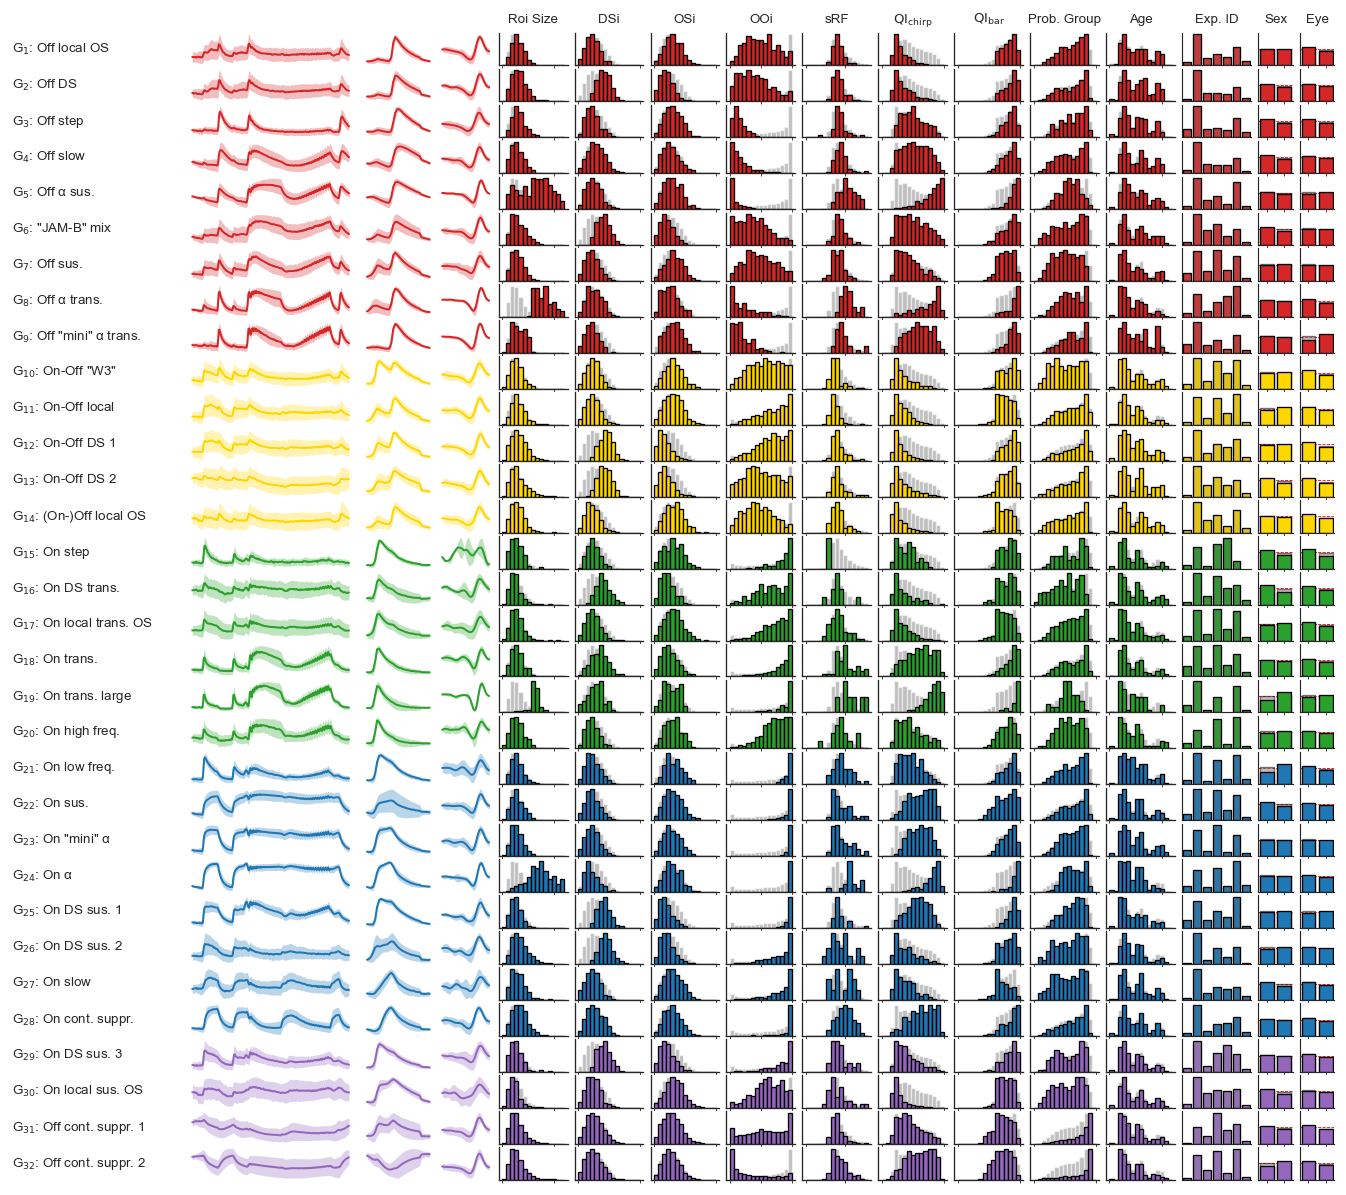

In [15]:
save = 1

n = 45
n_frames_chirp = chirp_data.shape[1]
n_frames_bar = bar_data_time.shape[1]
xlabel_fs = 8

fig, ax = plt.subplots(32, 11 + 4, figsize=(11, 10),
                       gridspec_kw={'width_ratios': [2.5, 1., 0.75, 1., 1., 1., 1., 1., 1., 1., 1, 1, 1, 0.5, 0.5]})

for i in range(0, 32):

    idx = np.where(all_gcl_df['group_id'] == i + 1)[0]

    # Chirp traces
    ax[i, 0].plot(np.mean(chirp_data[idx], axis=0), color=colors[i])
    ax[i, 0].fill_between(np.arange(0, n_frames_chirp, 1),
                          np.mean(chirp_data[idx], axis=0) + np.std(chirp_data[idx], axis=0),
                          np.mean(chirp_data[idx], axis=0) - np.std(chirp_data[idx], axis=0),
                          alpha=0.3,
                          color=colors[i],
                          edgecolor="b",
                          linewidth=0.0)
    ax[i, 0].axis('off')
    ax[i, 0].text(-1, 0.5, group_and_name_ticklabels[i],
                  transform=ax[i, 0].transAxes, rotation=0, va='center', ha='left', fontsize=8)

    # MB traces
    ax[i, 1].plot(np.roll(np.mean(bar_data_time[idx], axis=0), -5), color=colors[i])
    ax[i, 1].fill_between(np.arange(0, n_frames_bar, 1),
                          np.roll(np.mean(bar_data_time[idx], axis=0), -5) +
                          np.roll(np.std(bar_data_time[idx], axis=0), -5),
                          np.roll(np.mean(bar_data_time[idx], axis=0), -5) -
                          np.roll(np.std(bar_data_time[idx], axis=0), -5),
                          alpha=0.3,
                          color=colors[i],
                          edgecolor="b",
                          linewidth=0.0)
    ax[i, 1].axis('off')

    #### tRF
    filtered_trf_i = filtered_trf[filtered_trf['group_id'] == i + 1]['trf']
    if filtered_trf_i.empty:
        trf_array = np.zeros((0, 40))

    else:
        trf_array = np.stack(filtered_trf_i.values)

    ax[i, 2].plot(np.mean(trf_array, axis=0), color=colors[i])
    ax[i, 2].fill_between(np.arange(0, 40, 1),
                          np.mean(trf_array, axis=0) + np.std(trf_array, axis=0),
                          np.mean(trf_array, axis=0) - np.std(trf_array, axis=0),
                          alpha=0.3,
                          color=colors[i],
                          edgecolor="b",
                          linewidth=0.0)
    ax[i, 2].axis('off')

    #### roi size
    ax2 = ax[i, 3].twinx()
    #background
    ax[i, 3].hist(all_gcl_df['roi_size_um2'].values[:],
                  range=[0, 300],
                  bins=15,
                  color='gray',
                  alpha=0.5, zorder=2)
    ax[0, 3].set_title('ROI Size', fontsize=8)

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['roi_size_um2'].values[:],
             range=[0, 300],
             bins=15,
             edgecolor='k',
             color=colors[i], zorder=1, alpha=1)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 3].set_yticks([])
    ax2.set_yticks([])
    ax[i, 3].get_yaxis().set_visible(False)

    #### DSi
    ax2 = ax[i, 4].twinx()
    # background
    ax[i, 4].hist(all_gcl_df['bar_ds_index'].values[:],
                  range=[0, 1],
                  bins=15,
                  color='gray',
                  alpha=0.5)
    ax[0, 4].set_title('DSi', fontsize=8)
    ax[i, 4].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['bar_ds_index'].values[:],
             range=[0, 1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('DSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 4].set_yticks([])
    ax2.set_yticks([])
    ax[i, 4].get_yaxis().set_visible(False)

    #### OSi
    ax2 = ax[i, 5].twinx()
    # background
    ax[i, 5].hist(all_gcl_df['bar_os_index'].values[:],
                  range=[0, 1],
                  bins=15,
                  color='gray',
                  alpha=0.5)
    ax[0, 5].set_title('OSi', fontsize=8)
    ax[i, 5].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['bar_os_index'].values[:],
             range=[0, 1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 5].set_yticks([])
    ax2.set_yticks([])
    ax[i, 5].get_yaxis().set_visible(False)

    #### OOI
    ax2 = ax[i, 6].twinx()
    # background
    ax[i, 6].hist(all_gcl_df['chirp_on_off_index'].values[:],
                  range=[-1, 1],
                  bins=15,
                  color='gray',
                  alpha=0.5)
    ax[0, 6].set_title('OOi', fontsize=8)
    ax[i, 6].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['chirp_on_off_index'].values[:],
             range=[-1, 1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OOi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 6].set_yticks([])
    ax2.set_yticks([])
    ax[i, 6].get_yaxis().set_visible(False)

    #### spatial receptive field center diamener
    ax2 = ax[i, 7].twinx()
    # background
    ax[i, 7].hist(all_gcl_df['rf_cdia_um'].values[:],
                  range=[0, 400],
                  bins=15,
                  color='gray',
                  alpha=0.5)
    ax[0, 7].set_title('sRF', fontsize=8)
    ax[i, 7].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['rf_cdia_um'].values[:],
             range=[0, 400],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 7].set_yticks([])
    ax2.set_yticks([])
    ax[i, 7].get_yaxis().set_visible(False)

    #### Response Quality Chirp
    ax2 = ax[i, 8].twinx()
    # background
    ax[i, 8].hist(all_gcl_df['chirp_qidx'].values[:],
                  range=[0, 1],
                  bins=15,
                  color='gray',
                  alpha=0.5)
    ax[0, 8].set_title('$QI_{chirp}$', fontsize=8)
    ax[i, 8].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['chirp_qidx'].values[:],
             range=[0, 1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 8].set_yticks([])
    ax2.set_yticks([])
    ax[i, 8].get_yaxis().set_visible(False)

    #### Response Quality Moving Bar
    ax2 = ax[i, 9].twinx()
    # background
    ax[i, 9].hist(all_gcl_df['bar_qidx'].values[:],
                  range=[0, 1],
                  bins=15,
                  color='gray',
                  alpha=0.5)
    ax[0, 9].set_title('$QI_{bar}$', fontsize=8)
    ax[i, 9].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['bar_qidx'].values[:],
             range=[0, 1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 9].set_yticks([])
    ax2.set_yticks([])
    ax[i, 9].get_yaxis().set_visible(False)

    #### Confidence Score
    ax2 = ax[i, 10].twinx()
    # background
    ax[i, 10].hist(all_gcl_df['prob_group'].values[:],
                   range=[0, 1],
                   bins=15,
                   color='gray',
                   alpha=0.5)
    ax[0, 10].set_title('Prob. Group', fontsize=8)
    ax[i, 10].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['prob_group'].values[:],
             range=[0, 1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 10].set_yticks([])
    ax2.set_yticks([])
    ax[i, 10].get_yaxis().set_visible(False)

    #### age in weeks
    ax2 = ax[i, 11].twinx()
    # background
    ax[i, 11].hist(all_gcl_df['age_weeks'].values[:],
                   range=[0, 30],
                   bins=15,
                   color='gray',
                   alpha=0.5)
    ax[0, 11].set_title('Age', fontsize=8)
    ax[i, 11].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i + 1]['age_weeks'].values[:],
             range=[0, 30],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('RTi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i, 11].set_yticks([])
    ax2.set_yticks([])
    ax[i, 11].get_yaxis().set_visible(False)

    ##### experimenter distribution
    all_gcl_df['experimenter_id'] = all_gcl_df['experimenter_id'].astype('int').astype('string')
    subset = all_gcl_df[all_gcl_df['group_id'] == i + 1]
    experimenter_order = list(range(1, 8))
    sns.countplot(x='experimenter_id', data=subset, color=colors[i], edgecolor='black', order=experimenter_order,
                  ax=ax[i, 12])
    ax[i, 12].set_xticklabels('')
    ax[0, 12].set_title('Exp. ID', fontsize=8)
    ax[i, 12].get_yaxis().set_visible(False)
    ax[i, 12].get_xaxis().set_visible(False)
    ax[i, 12].set_yticks([])
    ax[i, 12].set_xticks([])

    # --- SEX ---
    labels_sex = ['male', 'female']
    x = np.array([0, 1])  # bar centers at 0 and 1
    width = 0.8

    sex_all = all_gcl_df['animgender'].astype(str).str.lower()
    perc_all = (sex_all[sex_all.isin(labels_sex)]
                .value_counts(normalize=True)
                .reindex(labels_sex).fillna(0.0).mul(100))

    sex_type = all_gcl_df.loc[all_gcl_df['group_id'] == i + 1, 'animgender'].astype(str).str.lower()
    perc_type = (sex_type[sex_type.isin(labels_sex)]
                 .value_counts(normalize=True)
                 .reindex(labels_sex).fillna(0.0).mul(100))

    ax[i, 13].bar(x, perc_all.values, width=width, color=['gray', 'gray'], edgecolor='k', alpha=0.5, zorder=1)
    ax[i, 13].bar(x, perc_type.values, width=width, color=[colors[i], colors[i]], edgecolor='k', zorder=2)
    ax[i, 13].set_xlim(-0.5, 1.5)
    ax[i, 13].set_ylim(0, 100)
    ax[i, 13].tick_params(labelbottom=False, left=False)
    ax[i, 13].yaxis.set_visible(False)
    if i == 0:
        ax[0, 13].set_title('Sex', fontsize=8)
    ax[i, 13].axhline(50, color='r', ls='--', lw=0.5, zorder=0)

    # --- EYE ---
    labels_eye = ['left', 'right']
    x = np.array([0, 1])  # same positions for eye
    width = 0.8

    eye_all = all_gcl_df['eye'].astype(str).str.lower()
    perc_all = (eye_all[eye_all.isin(labels_eye)]
                .value_counts(normalize=True)
                .reindex(labels_eye).fillna(0.0).mul(100))

    eye_type = all_gcl_df.loc[all_gcl_df['group_id'] == i + 1, 'eye'].astype(str).str.lower()
    perc_type = (eye_type[eye_type.isin(labels_eye)]
                 .value_counts(normalize=True)
                 .reindex(labels_eye).fillna(0.0).mul(100))

    ax[i, 14].bar(x, perc_all.values, width=width, color=['gray', 'gray'], edgecolor='k', alpha=0.5, zorder=1)
    ax[i, 14].bar(x, perc_type.values, width=width, color=[colors[i], colors[i]], edgecolor='k', zorder=2)
    ax[i, 14].set_xlim(-0.5, 1.5)
    ax[i, 14].set_ylim(0, 100)
    ax[i, 14].tick_params(labelbottom=False, left=False)
    ax[i, 14].yaxis.set_visible(False)
    if i == 0:
        ax[0, 14].set_title('Eye', fontsize=8)
    ax[i, 14].axhline(50, color='r', ls='--', lw=0.5, zorder=0)

sns.despine()
fig.tight_layout()
fig.subplots_adjust(wspace=0.1, hspace=0.1)

if save == 1:
    fig.patch.set_facecolor('white')
    fig.savefig(os.path.join(FIG_DIR, "celltype_function.png"),
                dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig(os.path.join(FIG_DIR, "celltype_function.svg"),
                dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), transparent=False)